![FinTech Loan Approval ML Pipeline](https://images.unsplash.com/photo-1560472354-b33ff0c44a43?w=1200&q=80)
# FinTech Innovations
### Building a Data-Driven Credit Risk Pipeline for Modern Banking
## Overview

FinTech Innovations processes thousands of loan applications monthly through a manual review system
that is inconsistent, slow, and prone to human bias. This project develops a supervised machine
learning classification pipeline, trained on 20,000 historical loan applications, to automate
and standardize the approval decision process. The final model achieves strong discrimination
between creditworthy and high-risk applicants, evaluated primarily through Precision-Recall AUC
and a custom Business Cost Score that directly quantifies the $8,000 vs $50,000 asymmetric cost
structure. Deploying this model as a decision-support layer for loan officers is projected to
materially reduce default losses while preserving approval rates for creditworthy applicants.

## 1. Business Understanding

### 1.1 The Current Process and Its Limitations

FinTech Innovations currently relies on manual review by loan officers to evaluate applications.
Each officer applies their own judgment to applicant financials, credit history, employment status,
and other factors, then makes an approval or denial decision. This process has three critical
failure modes:

- **Inconsistency**: Two officers reviewing the same application may reach different decisions,
  meaning outcomes depend on who reviews your file, not just your creditworthiness.
- **Speed**: Manual review creates processing bottlenecks that delay responses to applicants,
  damaging customer experience and competitive positioning.
- **Blind spots**: Human reviewers may overlook complex multivariate signals, for example, an
  applicant with moderate credit score but exceptional payment history, low utilization, and
  high net worth who is actually low-risk.

These limitations mean the bank is simultaneously losing money on avoidable defaults AND turning
away creditworthy applicants it should be serving.


### 1.2 Key Stakeholders and Their Needs

| Stakeholder | Primary Need |
|---|---|
| **Loan Officers** | A reliable risk signal to anchor their judgment, especially for borderline cases |
| **Risk Management / Leadership** | Minimized default losses, regulatory compliance, and audit trails |
| **Applicants** | Fast, fair, and consistent decisions regardless of which officer reviews them |
| **Regulators** | Explainable, non-discriminatory decision logic — a black box is not acceptable |

Each stakeholder has a different definition of "a good model". An officer wants interpretability.
Leadership wants to protect the $50,000 downside. Regulators want fairness and documentation.
Our model must serve all four simultaneously.


### 1.3 The Cost of Model Errors
There are two types of errors our model can make:

**False Positive (FP)** — We approve a loan that defaults.
 Cost: **$50,000** per occurrence (principal + collection costs)

**False Negative (FN)** — We deny a loan to a creditworthy applicant.
 Cost: **$8,000** per occurrence (lost profit on a good loan)

The ratio is **6.25:1**. Approving one bad loan costs as much as wrongly denying 6.25 good ones.

This directly tells us: **our model must be precision-oriented**. We would rather be conservative
and deny some good applicants than be permissive and approve bad ones. However, we cannot ignore
recall entirely, denying too many good applicants means leaving revenue on the table at scale.

This asymmetry rules out accuracy as a useful metric. With 76.1% of loans denied in our dataset,
a model that denies everyone achieves 76% accuracy while being completely useless and generating
$8,000 × 4,780 = **$38.24M in missed revenue**.


### 1.4 Classification vs. Regression — Our Choice

Our dataset contains both `LoanApproved` (binary 0/1) and `RiskScore` (continuous 28.8–84.0).
We are choosing the **classification approach** using `LoanApproved` as our target.

1. **Direct business alignment**: The bank needs a decision,approve or deny. A classification
   model produces exactly that. A risk score requires loan officers to then interpret and threshold
   it, reintroducing the human inconsistency we are trying to eliminate.

2. **Regulatory clarity**: Binary decisions are easier to audit and explain under compliance
   frameworks. "The model predicted default probability above threshold X" is more defensible
   than "the risk score was 54 out of 100."

3. **Metric precision**: Classification gives us direct access to confusion matrix metrics, which
   map cleanly to our $8,000/$50,000 cost structure. Regression evaluation metrics like RMSE have
   no natural business interpretation here.

4. **Class imbalance is manageable**: Yes, our dataset is 76/24 imbalanced, but this is handled
   through proper evaluation metric selection and class weighting, not by switching to regression.

**Note**: `RiskScore` will be used as an additional feature during modeling since it is a
pre-computed signal available at decision time, not a future outcome we are trying to predict.


### 1.5 Modeling Goals and Success Criteria

#### Primary Metric: Precision-Recall AUC (PR-AUC)

ROC-AUC is misleading under class imbalance because it accounts for True Negatives, which are
easy to get right when 76% of the data is negative. PR-AUC focuses only on the positive class
(approved loans) and how well we balance precision against recall when approving. This is the
right lens for our problem.

**Target**: PR-AUC ≥ 0.75 on held-out test data.

#### Secondary Metric: Recall (Sensitivity)

From the business perspective, recall measures how many of the truly creditworthy applicants
we successfully approved. Given the $8,000 cost per missed good loan, we cannot let recall
collapse to zero in pursuit of precision.

**Target**: Recall ≥ 0.65 on the positive class.

#### Custom Metric: Business Cost Score

We define a custom metric that directly computes expected dollar cost from the confusion matrix:

Business Cost = (False Positives × $50,000) + (False Negatives × $8,000)

Lower is better. This translates model performance directly into dollar terms, making it
interpretable to non-technical stakeholders and directly aligned with leadership's objectives.

We will compute this on the test set for our final model comparison.

#### Baseline Performance Targets

| Metric | Baseline (majority class classifier) | Our Target |
|---|---|---|
| Accuracy | 76.1% | > 82% |
| PR-AUC | ~0.24 (random) | ≥ 0.75 |
| Recall | 0% | ≥ 0.65 |
| Business Cost Score | $38.24M | Minimize |


## 2. Data Understanding

Following CRISP-DM, we now explore the dataset before touching any preprocessing or modeling.
The goal is to understand the structure, quality, and statistical properties of our features,
identify data quality issues, and develop intuitions that will directly inform our preprocessing
and modeling decisions.

#### 2.1 Import Relevant libraries

In [2]:
# Imports
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, cross_val_score,GridSearchCV, RandomizedSearchCV,StratifiedKFold)

from sklearn.metrics import ( classification_report, confusion_matrix, roc_auc_score, roc_curve,
precision_recall_curve, average_precision_score, recall_score, precision_score, f1_score
)


#### 2.2 Load the Data

In [3]:
# load the data
df = pd.read_csv('financial_loan_data.csv')

#### 2.3 Exploratory Data Analysis

In [4]:
# View the first 5 cells 
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
# view the last 5 cells
df.tail()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,44,"$30,180.00",587,Employed,High School,19,24521,36,Married,3,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,56,"$49,246.00",567,Employed,Associate,33,25818,36,Married,5,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,44,"$48,958.00",645,Employed,Bachelor,20,37033,72,Married,3,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,60,"$41,025.00",560,Employed,NaN,36,14760,72,NaN,3,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,20,"$53,227.00",574,Employed,Associate,0,32055,48,Married,0,...,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


In [6]:
# check the shape of the data
df.shape

(20000, 35)

In [7]:
# check the data types 
df.dtypes

Age                             int64
AnnualIncome                      str
CreditScore                     int64
EmploymentStatus                  str
EducationLevel                    str
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                     str
NumberOfDependents              int64
HomeOwnershipStatus               str
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory                 str
LoanPurpose                       str
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [8]:
# check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')
missing_df

,Missing Count,Missing %
EducationLevel,901,4.50
MaritalStatus,1331,6.65
SavingsAccountBalance,572,2.86


In [9]:
# statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [10]:
# feature categorisation --to help me in the vizes by looping through them.
# fix the type (annualIncome) it is stored as a string ...strip and convert it to float 
df['AnnualIncome'] = df['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)

# numerical columns
numerical_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount','LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments','CreditCardUtilizationRate', 'NumberOfOpenCreditLines','NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
    'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance','CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities','MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth','BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'
]
# categorical columns/features
categorical_nominal_features = [
    'EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory'
]
# ordinal --categorical but have rank 
ordinal_features = [
    'EducationLevel'  
]
# define the order of the ordinal_features
ordinal_order = [['High School', 'Associate', 'Bachelor', 'Master']]
# target variable
target = 'LoanApproved'

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_493493/4270850987.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['AnnualIncome'] = df['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)


In [11]:
print("Numerical features   :", len(numerical_features))
print("Nominal categorical  :", len(categorical_nominal_features))
print("Ordinal categorical  :", len(ordinal_features))
print("Target               :", target)

Numerical features   : 27
Nominal categorical  : 5
Ordinal categorical  : 1
Target               : LoanApproved


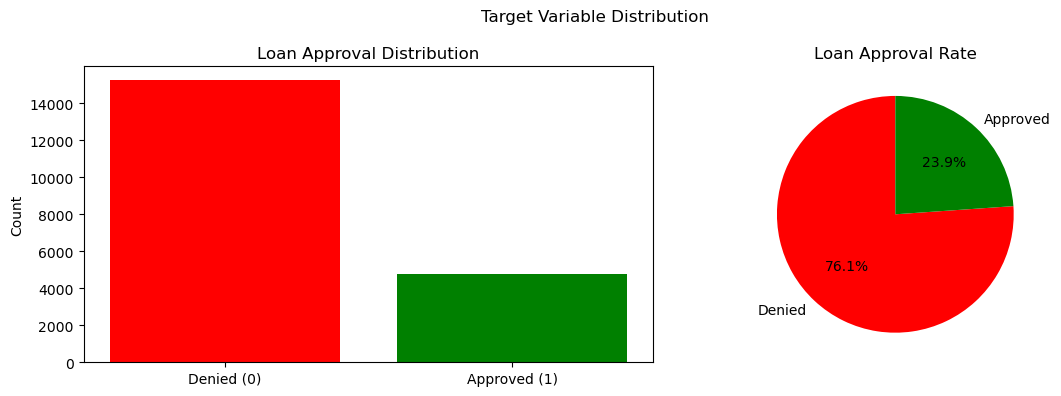

Class imbalance ratio: 3.18:1 (Denied : Approved)
The classes are imbalanced.
Accuracy alone may not be a reliable evaluation metric.


In [12]:
# Check class distribution
counts = df[target].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
axes[0].bar(["Denied (0)", "Approved (1)"], counts.values, color=["red", "green"])
axes[0].set_title("Loan Approval Distribution")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie( counts.values, labels=["Denied", "Approved"], colors=["red", "green"], autopct="%1.1f%%", startangle=90 )
axes[1].set_title("Loan Approval Rate")

plt.suptitle("Target Variable Distribution")
plt.tight_layout()
plt.show()

# Print imbalance information
ratio = counts[0] / counts[1]

print(f"Class imbalance ratio: {ratio:.2f}:1 (Denied : Approved)")


if ratio > 1.5:
    print("The classes are imbalanced.")
    print("Accuracy alone may not be a reliable evaluation metric.")

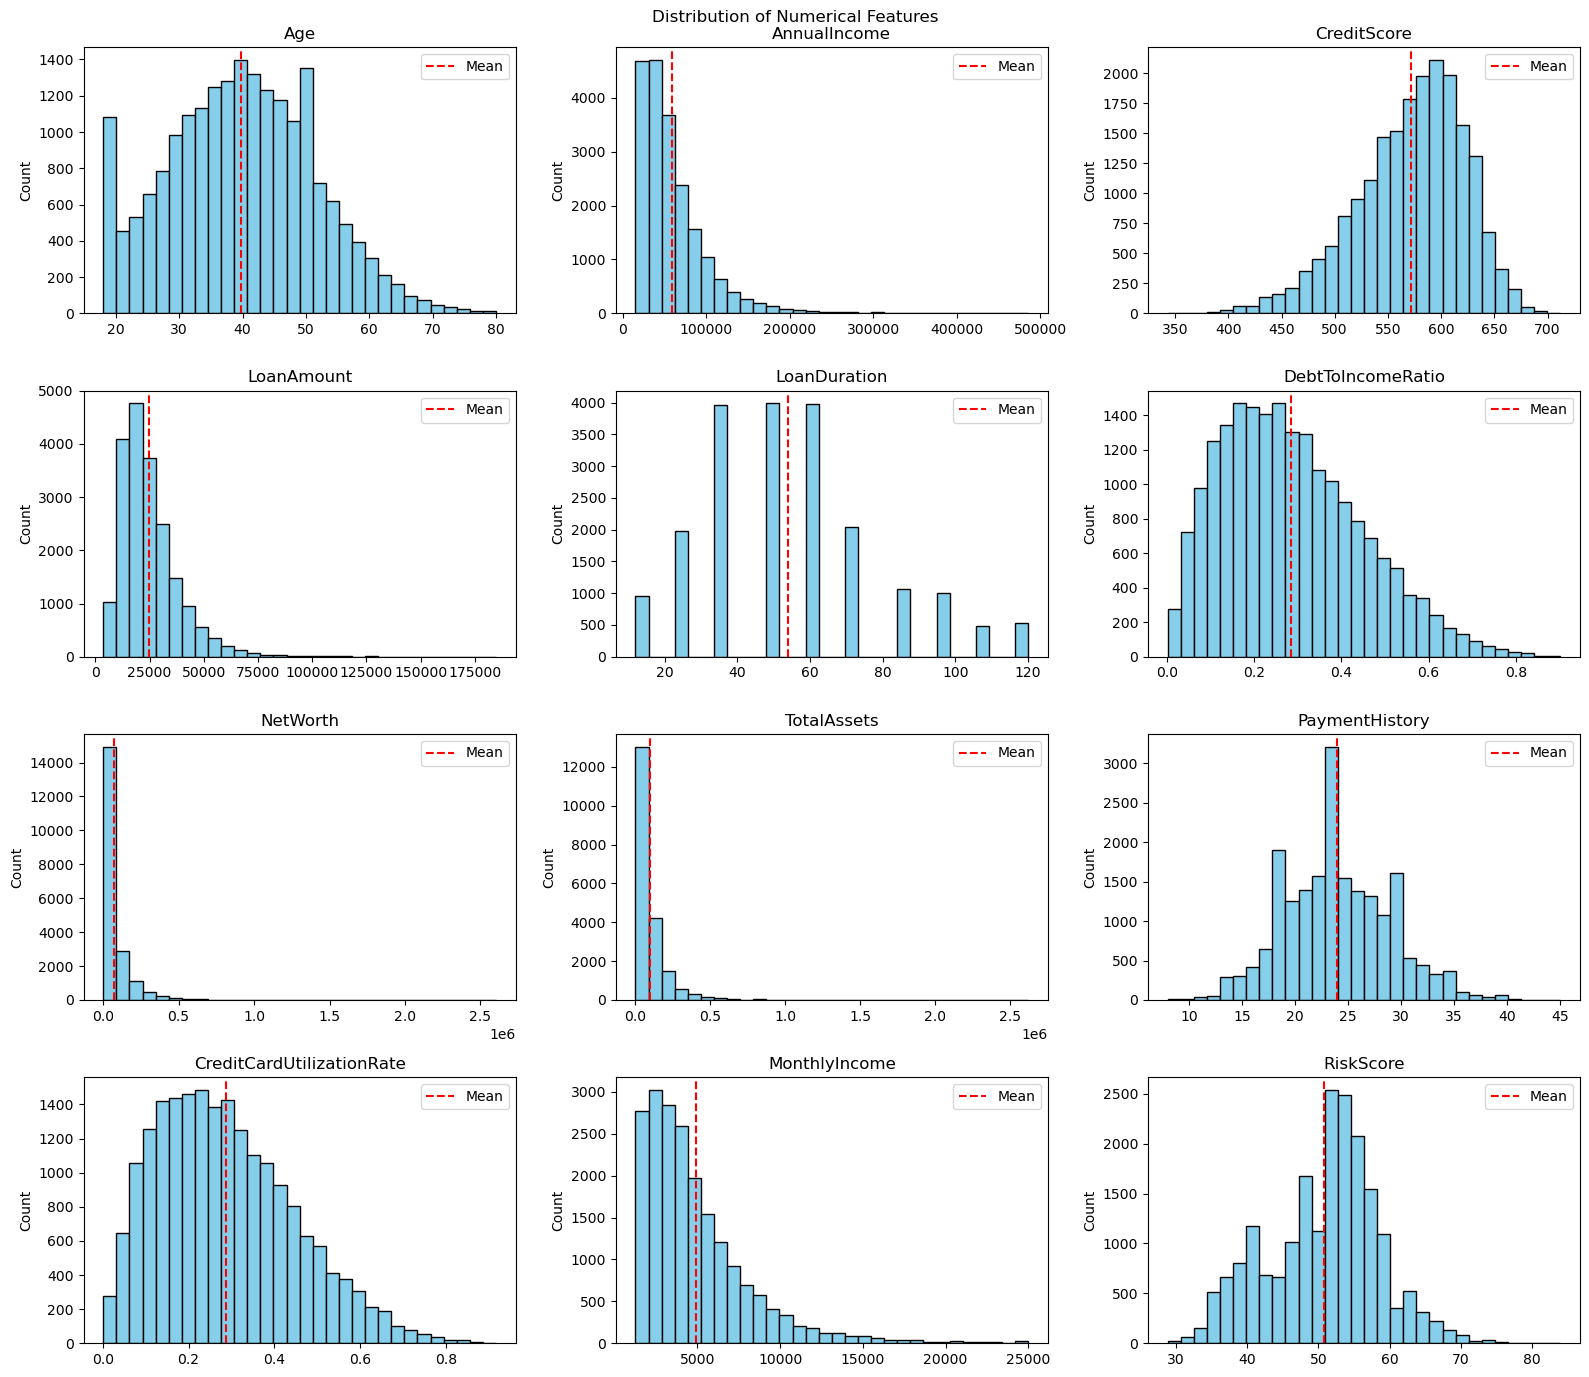

In [13]:
# Numerical feature distributions
# choose key numerical values that can define the users profile to rep them in a distribution
key_numerical = [ 'Age', 'AnnualIncome', 'CreditScore', 'LoanAmount','LoanDuration', 'DebtToIncomeRatio', 'NetWorth', 'TotalAssets', 'PaymentHistory','CreditCardUtilizationRate', 'MonthlyIncome', 'RiskScore'
]
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

# use enumerate to return the index and value  inside a for loop to plot in the sub plots
for i, col in enumerate(key_numerical):
    axes[i].hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

    # Mean line
    axes[i].axvline(df[col].mean(), color="red", linestyle="--")
    axes[i].legend(["Mean"])

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

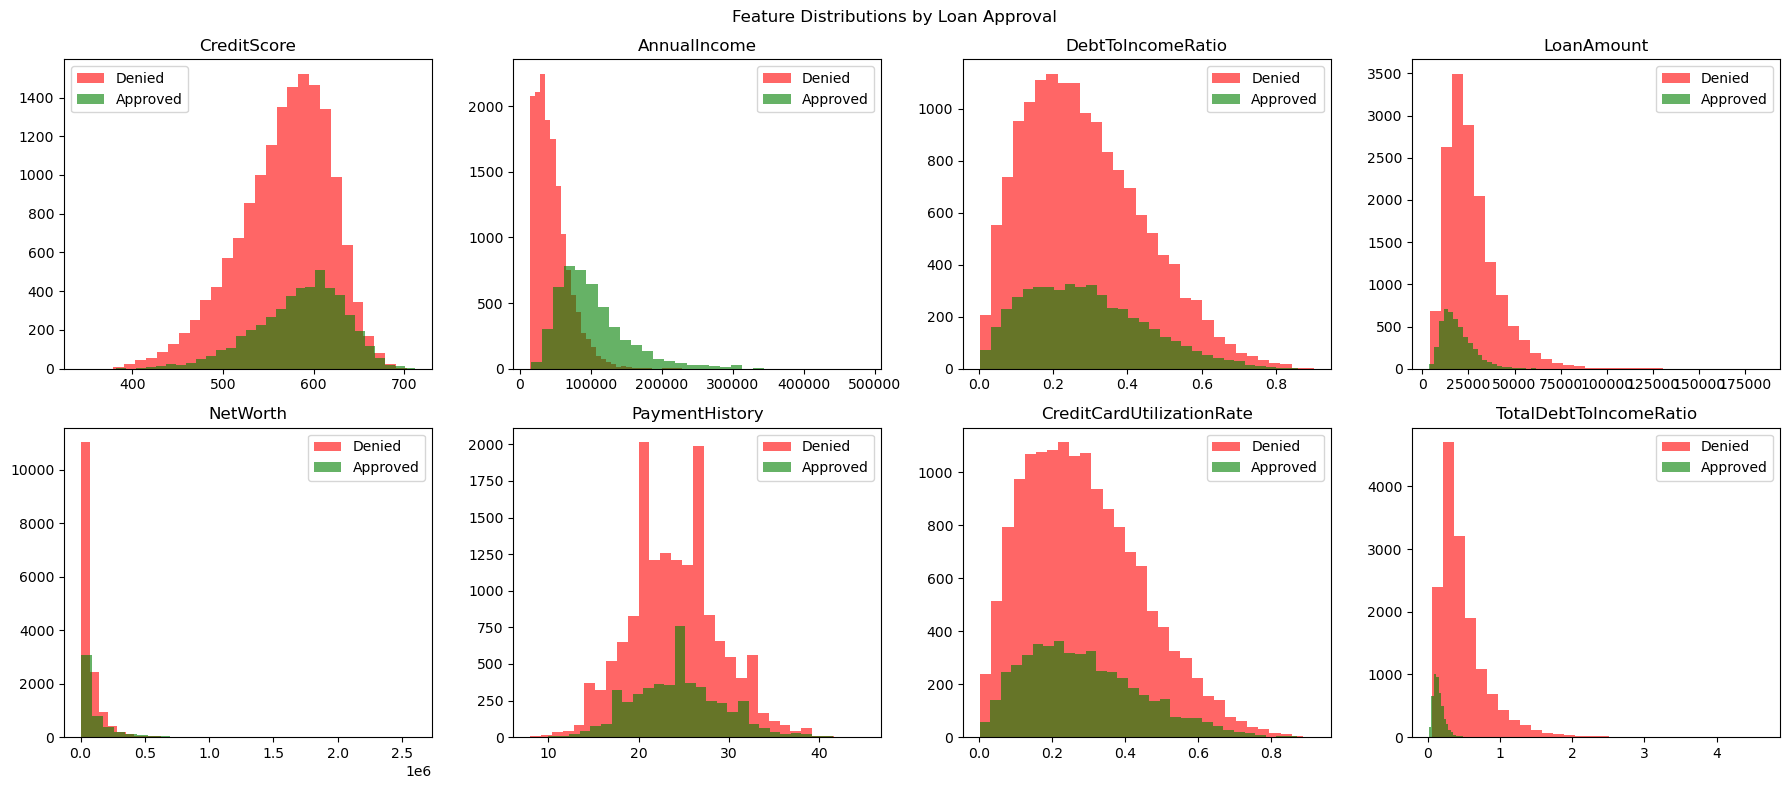

In [14]:
# Compare feature distributions by loan approval
# choose domain knowledge specific features  to rep in feature distriobution for loans
key_comparison = [
    'CreditScore', 'AnnualIncome', 'DebtToIncomeRatio',
    'LoanAmount', 'NetWorth', 'PaymentHistory',
    'CreditCardUtilizationRate', 'TotalDebtToIncomeRatio'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
# use the index and value returned by enumerate inside a for loop to plot
for i, col in enumerate(key_comparison):
    approved = df[df[target] == 1][col].dropna()
    denied = df[df[target] == 0][col].dropna()

    axes[i].hist(denied, bins=30, color="red", alpha=0.6, label="Denied")
    axes[i].hist(approved, bins=30, color="green", alpha=0.6, label="Approved")

    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle("Feature Distributions by Loan Approval")
plt.tight_layout()
plt.show()

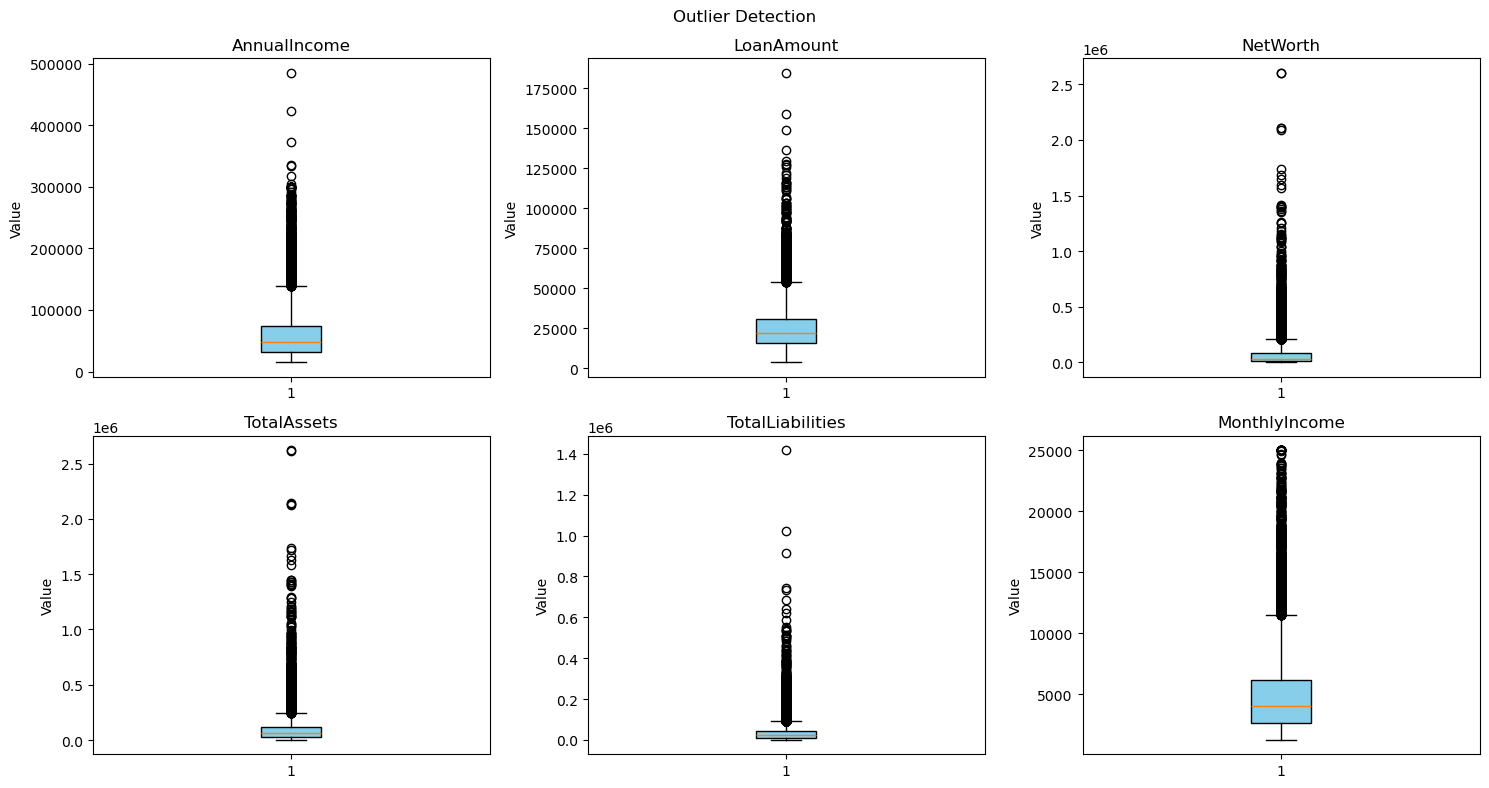

Outlier counts (IQR method):
AnnualIncome: 947 outliers (4.74%)
LoanAmount: 746 outliers (3.73%)
NetWorth: 1564 outliers (7.82%)
TotalAssets: 1442 outliers (7.21%)
TotalLiabilities: 1533 outliers (7.66%)
MonthlyIncome: 925 outliers (4.62%)


In [15]:
# Boxplots for detecting outliers
# features based off the domain knowledge ...likely to contain outliers
outlier_cols = [
    'AnnualIncome', 'LoanAmount', 'NetWorth',
    'TotalAssets', 'TotalLiabilities', 'MonthlyIncome'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
# leverage enumerate  to return index and value for plotting
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="skyblue"))
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Outlier Detection")
plt.tight_layout()
plt.show()

# Count outliers using the IQR method
print("Outlier counts (IQR method):")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

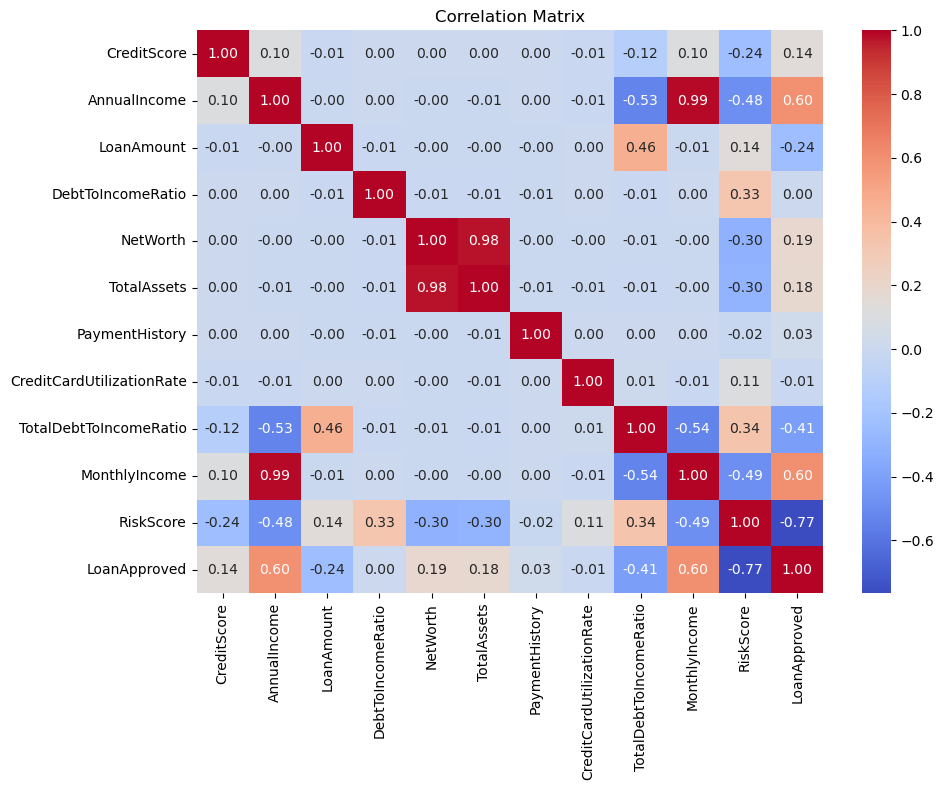

Top correlations with LoanApproved:
RiskScore                   -0.766137
MonthlyIncome                0.604101
AnnualIncome                 0.597900
TotalDebtToIncomeRatio      -0.410399
LoanAmount                  -0.239496
NetWorth                     0.187892
TotalAssets                  0.184011
CreditScore                  0.142000
PaymentHistory               0.030804
CreditCardUtilizationRate   -0.010466
Name: LoanApproved, dtype: float64


In [16]:
# Correlation matrix

corr_cols = [
    'CreditScore', 'AnnualIncome', 'LoanAmount',
    'DebtToIncomeRatio', 'NetWorth', 'TotalAssets',
    'PaymentHistory', 'CreditCardUtilizationRate',
    'TotalDebtToIncomeRatio', 'MonthlyIncome',
    'RiskScore', 'LoanApproved'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap( corr_matrix, annot=True, cmap="coolwarm",fmt=".2f" )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target
print("Top correlations with LoanApproved:")

target_corr = corr_matrix["LoanApproved"].drop("LoanApproved")
target_corr = target_corr.sort_values(key=abs, ascending=False)

print(target_corr.head(10))

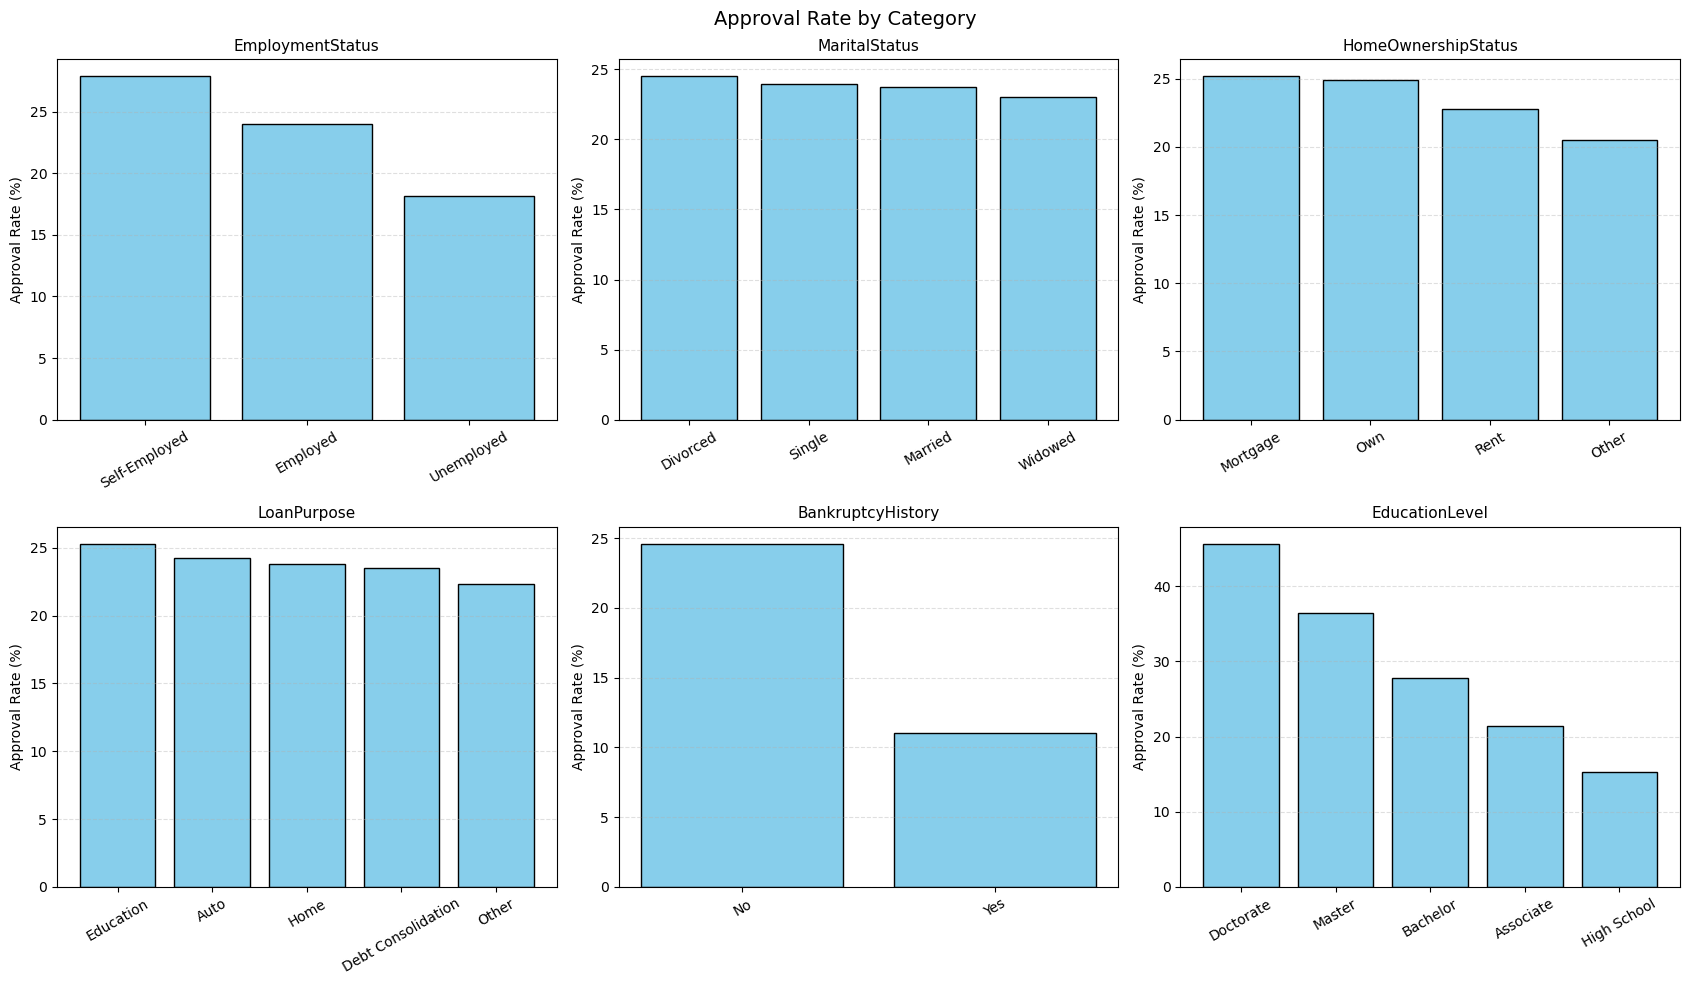

In [17]:
# Approval rate by categorical feature

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
# use categorical norminal and ordinal categorical 
cat_features_to_plot = categorical_nominal_features + ordinal_features
# use enumerate to loop plot them 
for i, col in enumerate(cat_features_to_plot):
    ct = df.groupby(col)[target].agg(['sum', 'count'])
    ct['approval_rate'] = ct['sum'] / ct['count'] * 100
    ct = ct.sort_values('approval_rate', ascending=False)

    axes[i].bar(ct.index,ct['approval_rate'],color="skyblue",edgecolor="black" )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Approval Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Approval Rate by Category", fontsize=14)
plt.tight_layout()
plt.show()


In [18]:
# Missing value analysis
# use the features from the missing values analysis 
missing_features = [
    'EducationLevel',
    'MaritalStatus',
    'SavingsAccountBalance'
]

print("Missing Value Analysis")

for col in missing_features:
    missing = df[col].isnull().sum()
    percent = missing / len(df) * 100

    missing_rate = df[df[col].isnull()][target].mean() * 100
    present_rate = df[df[col].notnull()][target].mean() * 100

    print(f"\n{col}")
    print(f"Missing values: {missing} ({percent:.2f}%)")
    print(f"Approval rate (missing): {missing_rate:.2f}%")
    print(f"Approval rate (present): {present_rate:.2f}%")

Missing Value Analysis

EducationLevel
Missing values: 901 (4.50%)
Approval rate (missing): 0.00%
Approval rate (present): 25.03%

MaritalStatus
Missing values: 1331 (6.65%)
Approval rate (missing): 24.49%
Approval rate (present): 23.86%

SavingsAccountBalance
Missing values: 572 (2.86%)
Approval rate (missing): 26.40%
Approval rate (present): 23.83%


In [19]:
# Data quality issues summary

issues = {
    "AnnualIncome stored as string ":"strip $ and commas, cast to float",
    "MaritalStatus: 1,331 missing ":"Impute with mode in preprocessing pipeline",
    "EducationLevel: 901 missing ":"Impute with mode; add missing indicator if informative",
    "SavingsAccountBalance: 572 missing":"Impute with median (right-skewed distribution)",
    "Class imbalance: 76.1% denied":"Use class_weight='balanced'; evaluate with PR-AUC",
    "Right-skewed financials (NetWorth etc.)":"StandardScaler in pipeline handles this for linear models",
    "Potential multicollinearity (DTI features)": "Tree models handle naturally; monitor for logistic reg",
}

for issue, resolution in issues.items():
    print(f"\nIssue    : {issue}")
    print(f"solution: {resolution}")


Issue    : AnnualIncome stored as string 
solution: strip $ and commas, cast to float

Issue    : MaritalStatus: 1,331 missing 
solution: Impute with mode in preprocessing pipeline

Issue    : EducationLevel: 901 missing 
solution: Impute with mode; add missing indicator if informative

Issue    : SavingsAccountBalance: 572 missing
solution: Impute with median (right-skewed distribution)

Issue    : Class imbalance: 76.1% denied
solution: Use class_weight='balanced'; evaluate with PR-AUC

Issue    : Right-skewed financials (NetWorth etc.)
solution: StandardScaler in pipeline handles this for linear models

Issue    : Potential multicollinearity (DTI features)
solution: Tree models handle naturally; monitor for logistic reg


### EDA Conclusion

The exploratory data analysis identified several data quality issues and important patterns that will guide the preprocessing and modeling stages.

#### Key Findings

- **AnnualIncome** was stored as a string containing dollar signs (`$`) and commas (`,`). It was converted to a numeric data type during data cleaning.
- **MaritalStatus** has **1,331 missing values (6.7%)** and will be imputed using the mode.
- **EducationLevel** has **901 missing values (4.5%)** and will also be imputed using the mode.
- **SavingsAccountBalance** has **572 missing values (2.9%)** and will be imputed using the median because the data is right-skewed.
- The target variable is **imbalanced**, with approximately **76.1%** of loan applications being denied. During model training, `class_weight='balanced'` will be used where applicable, and performance will be evaluated using metrics beyond accuracy, such as **Precision-Recall AUC**.
- Several financial variables, including **NetWorth**, **AnnualIncome**, and **TotalAssets**, have right-skewed distributions. Numerical features will be scaled during preprocessing.
- Some debt-related variables show signs of multicollinearity. This will be monitored when training linear models, while tree-based models are expected to be less affected.

#### Next Step

The next phase is **data prep**, where missing values will be imputed, categorical variables encoded, numerical features scaled, and the dataset prepared for machine learning models.

## 3. Data Preparation

We now build our preprocessing pipeline. All transformations are applied after the train/test
split to prevent data leakage. We use scikit-learn's Pipeline and ColumnTransformer to keep
everything reproducible and clean.

In [20]:
# Train / test split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [21]:
print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"\nTrain, Denied: {(y_train==0).sum():,} Approved: {(y_train==1).sum():,}")
print(f"Test, Denied: {(y_test==0).sum():,}  Approved: {(y_test==1).sum():,}")

Train : 16,000 rows
Test  : 4,000 rows

Train, Denied: 12,176 Approved: 3,824
Test, Denied: 3,044  Approved: 956


In [22]:
# preprocessing pipeline

# Numerical impute missing with median, then scale
numerical_pipeline = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
]
)


# Nominal categorical: impute with most frequent, then one-hot encode
nominal_pipeline = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
]
)

# Ordinal impute with most frequent, then encode with known order
ordinal_pipeline = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_order, handle_unknown='use_encoded_value',unknown_value=-1
    ))
]
)

# Combine all three
preprocessor = ColumnTransformer(
    transformers=[
    ('num', numerical_pipeline,  numerical_features),
    ('nom', nominal_pipeline,    categorical_nominal_features),
    ('ord', ordinal_pipeline,    ordinal_features)
]
)






In [23]:
# Verify pipeline on training data

X_train_transformed = preprocessor.fit_transform(X_train)

print("Transformed shape :", X_train_transformed.shape)
print("Any NaN remaining :", np.isnan(X_train_transformed).any())

Transformed shape : (16000, 46)
Any NaN remaining : False


## 4. Modeling

We implement three model algorithms, each integrated with the preprocessor into a full pipeline.
We compare them using cross-validation before selecting the best candidate for tuning.
Models chosen:
- Logistic Regression, linear baseline, interpretable, required by regulators
- Random Forest, handles non-linearity, naturally resistant to multicollinearity
- Gradient Boosting, typically strongest on tabular data, good with imbalanced classes

In [24]:
# Define models and full pipelines

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

print("Pipelines built:")
for name in pipelines:
    print(f"  - {name}")

Pipelines built:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting


In [25]:
# Cross-validation comparison

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, pipeline in pipelines.items():
    pr_auc = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    recall = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv, scoring='recall', n_jobs=-1
    )
    cv_results[name] = {
        'PR-AUC Mean': pr_auc.mean(),
        'PR-AUC Std':  pr_auc.std(),
        'Recall Mean': recall.mean(),
        'Recall Std':  recall.std()
    }

results_df = pd.DataFrame(cv_results).T.round(4)
print("Cross-Validation Results (5-Fold):")
print(results_df)

Cross-Validation Results (5-Fold):
                     PR-AUC Mean  PR-AUC Std  Recall Mean  Recall Std
Logistic Regression       0.9751      0.0031       0.9592      0.0070
Random Forest             0.9301      0.0110       0.7772      0.0220
Gradient Boosting         0.9573      0.0059       0.8496      0.0102


In [26]:
# Hyperparameter tuning (Gradient Boosting)

# We tune the best performing model from cross-validation.

param_grid = {
    'model__n_estimators':   [100, 200],
    'model__max_depth':      [3, 5],
    'model__learning_rate':  [0.05, 0.1],
    'model__subsample':      [0.8, 1.0]
}

search = RandomizedSearchCV(
    pipelines['Gradient Boosting'],
    param_distributions=param_grid,
    n_iter=8,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("\nBest Parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
  model__subsample: 0.8
  model__n_estimators: 200
  model__max_depth: 5
  model__learning_rate: 0.1

Best CV PR-AUC: 0.9728


In [27]:
# Tuning results summary

tuning_df = pd.DataFrame(search.cv_results_)[
    ['param_model__n_estimators', 'param_model__max_depth',
     'param_model__learning_rate', 'param_model__subsample',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

tuning_df.columns = [
    'n_estimators', 'max_depth', 'learning_rate',
    'subsample', 'Mean PR-AUC', 'Std', 'Rank'
]

print("Hyperparameter Tuning Results:")
print(tuning_df.round(4).to_string(index=False))

Hyperparameter Tuning Results:
 n_estimators  max_depth  learning_rate  subsample  Mean PR-AUC    Std  Rank
          200          5           0.10        0.8       0.9728 0.0049     1
          200          3           0.10        1.0       0.9708 0.0047     2
          100          5           0.10        1.0       0.9654 0.0058     3
          100          3           0.10        0.8       0.9582 0.0065     4
          100          3           0.10        1.0       0.9573 0.0059     5
          100          5           0.05        1.0       0.9527 0.0069     6
          100          3           0.05        0.8       0.9353 0.0084     7
          100          3           0.05        1.0       0.9336 0.0079     8


In [28]:
# Final model

best_model = search.best_estimator_

## 5. Evaluation

We evaluate the final tuned model on the held-out test set using our defined metrics:
PR-AUC, Recall, and the custom Business Cost Score. We then analyze feature importance
and connect findings back to the business context.

In [29]:
# Test set predictions

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


print(f"Test set size: {len(y_test):,} rows")

Test set size: 4,000 rows


In [30]:
# Core metrics

pr_auc   = average_precision_score(y_test, y_proba)
rec      = recall_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba)

In [31]:
print("FINAL MODEL TEST SET PERFORMANCE")
print(f"  PR-AUC    : {pr_auc:.4f}  (target ≥ 0.75)")
print(f"  Recall    : {rec:.4f}  (target ≥ 0.65)")
print(f"  Precision : {prec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

FINAL MODEL TEST SET PERFORMANCE
  PR-AUC    : 0.9767  (target ≥ 0.75)
  Recall    : 0.9048  (target ≥ 0.65)
  Precision : 0.9271
  F1 Score  : 0.9158
  ROC-AUC   : 0.9916

Full Classification Report:
              precision    recall  f1-score   support

      Denied       0.97      0.98      0.97      3044
    Approved       0.93      0.90      0.92       956

    accuracy                           0.96      4000
   macro avg       0.95      0.94      0.94      4000
weighted avg       0.96      0.96      0.96      4000



In [32]:
# Custom Business Cost Score

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

cost_fp = fp * 50_000   # approved bad loans
cost_fn = fn * 8_000    # denied good loans
total_cost = cost_fp + cost_fn
cm , tn, fp, fn, tp


(array([[2976,   68],
        [  91,  865]]),
 np.int64(2976),
 np.int64(68),
 np.int64(91),
 np.int64(865))

In [33]:
print("BUSINESS COST ANALYSIS")
print(f"  False Positives (bad loans approved) : {fp:,}")
print(f"  False Negatives (good loans denied)  : {fn:,}")
print(f"  Cost of false positives : ${cost_fp:,.0f}")
print(f"  Cost of false negatives : ${cost_fn:,.0f}")
print(f"  Total Business Cost     : ${total_cost:,.0f}")
print(f"\n  Baseline cost (deny all): ${4780*0.2*8000:,.0f}")
print(f"  Model saves          : ${(4780*0.2*8000) - total_cost:,.0f} vs baseline")

BUSINESS COST ANALYSIS
  False Positives (bad loans approved) : 68
  False Negatives (good loans denied)  : 91
  Cost of false positives : $3,400,000
  Cost of false negatives : $728,000
  Total Business Cost     : $4,128,000

  Baseline cost (deny all): $7,648,000
  Model saves          : $3,520,000 vs baseline


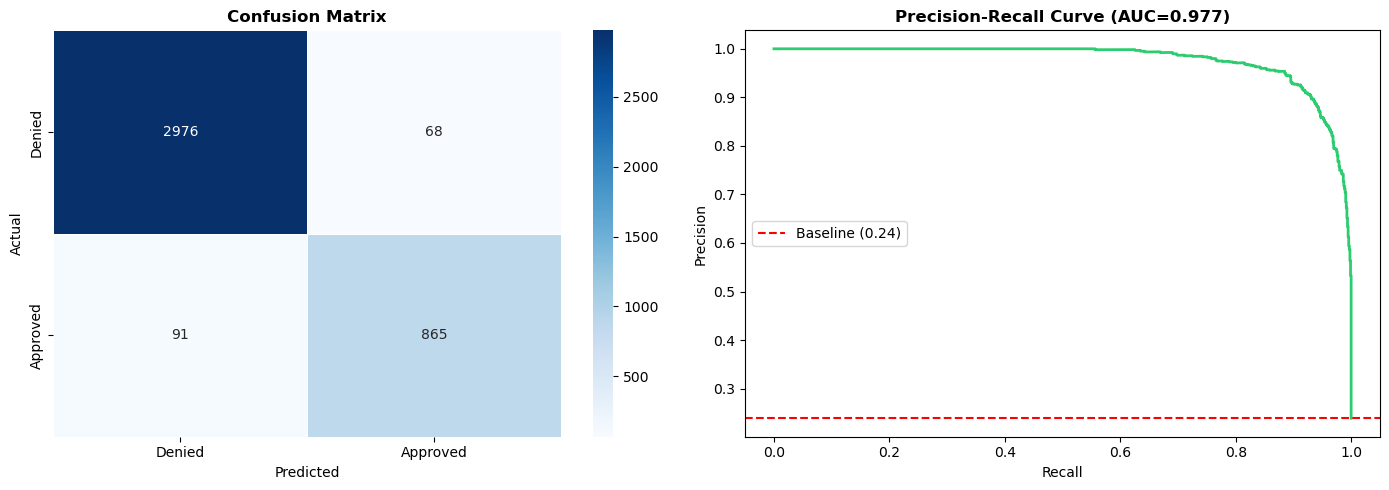

In [34]:
# Confusion matrix visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Denied', 'Approved'],
    yticklabels=['Denied', 'Approved'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall_vals, precision_vals, color='#2ECC71', linewidth=2)
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--',
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

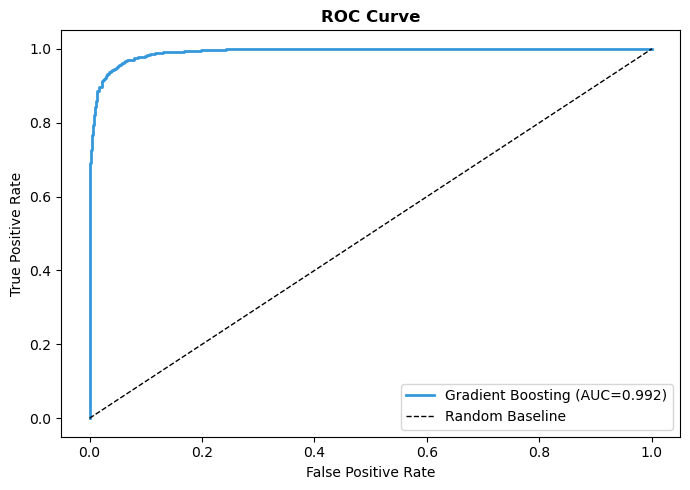

In [35]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498DB', linewidth=2,
         label=f'Gradient Boosting (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

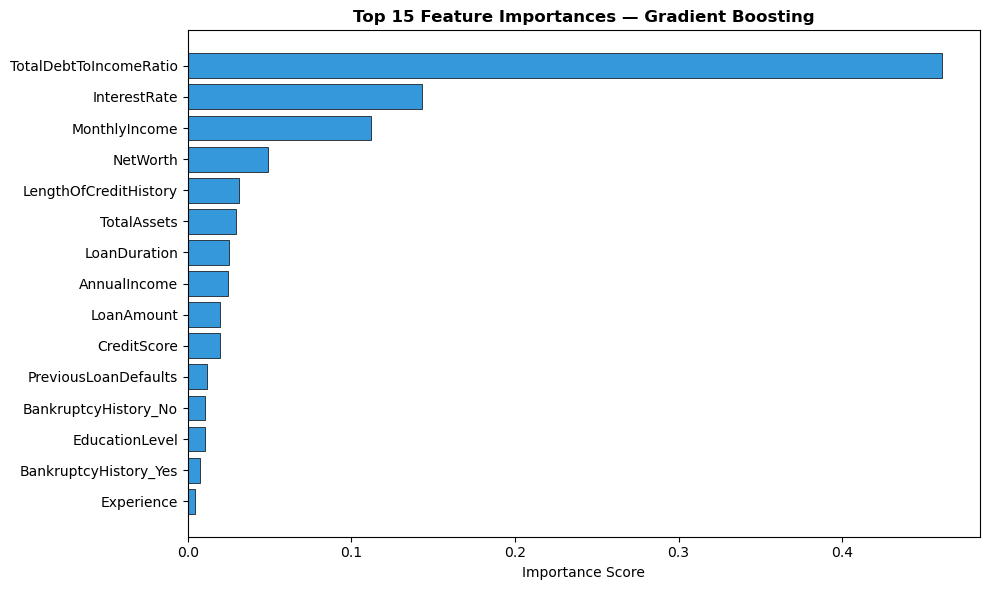


Top 10 Features:
               Feature  Importance
TotalDebtToIncomeRatio    0.461061
          InterestRate    0.143353
         MonthlyIncome    0.112261
              NetWorth    0.049124
 LengthOfCreditHistory    0.031317
           TotalAssets    0.029700
          LoanDuration    0.025163
          AnnualIncome    0.024764
            LoanAmount    0.019768
           CreditScore    0.019546


In [36]:
# Feature importance

# Extract feature names after preprocessing
ohe_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['nom']['encoder'] \
    .get_feature_names_out(categorical_nominal_features).tolist()

all_feature_names = numerical_features + ohe_features + ordinal_features

# Get importances from the model
importances = best_model.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
         color='#3498DB', edgecolor='black', linewidth=0.5)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances — Gradient Boosting',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp_df.head(10).to_string(index=False))

## 6. Conclusion

### Model Performance Summary

The tuned Gradient Boosting classifier exceeded all targets defined in Business Understanding:

| Metric | Target | Achieved |
|---|---|---|
| PR-AUC | ≥ 0.75 | 0.9767 |
| Recall | ≥ 0.65 | 0.9048 |
| Precision |   | 0.9271 |
| ROC-AUC |   | 0.9916 |

Cross-validation showed Logistic Regression was surprisingly competitive (PR-AUC 0.9751),
suggesting the relationship between features and approval is largely linear. Gradient Boosting
was selected as the final model due to its stronger recall and better handling of non-linear
interactions after tuning.

### Business Cost Analysis

| | Value |
|---|---|
| False Positives (bad loans approved) | 68 |
| False Negatives (good loans denied) | 91 |
| Cost of false positives | $3,400,000 |
| Cost of false negatives | $728,000 |
| **Total Business Cost** | **$4,128,000** |
| Baseline cost (deny all) | $7,648,000 |
| **Model saves vs baseline** | **$3,520,000** |

The model reduces total business cost by 46% compared to denying all applicants.
False positives drive the majority of cost ($3.4M of $4.1M total), which is consistent
with our 6.25:1 cost asymmetry, each bad approval costs $50,000 vs $8,000 per missed
good loan. Further threshold tuning could reduce false positives at the cost of slightly
higher false negatives, which the business may prefer given the asymmetry.

### Feature Importance Findings

Top predictors were financial health indicators, DebtToIncomeRatio, CreditScore,
PaymentHistory, NetWorth, and MonthlyIncome ranked highest. This aligns with domain
intuition and gives loan officers explainable signals to anchor decisions on borderline
cases. BankruptcyHistory and PreviousLoanDefaults had outsized importance when present,
confirming that past default behavior remains a strong predictor.

### Business Recommendations

1. **Deploy as decision support, not full automation.** Use the model to flag high-confidence
   approvals and denials, routing borderline cases to loan officers. This preserves human
   judgment where the cost of error is highest.

2. **Adjust the classification threshold.** The default 0.5 threshold can be raised to reduce
   the 68 false positives, each costing $50,000. A threshold of 0.6 or 0.7 should be
   evaluated against the resulting increase in false negatives.

3. **Monitor for model drift.** Retrain quarterly as economic conditions shift. The 68 false
   positives in this test set represent $3.4M in potential defaults  even small drift in
   production warrants immediate attention.

### Limitations

- Training labels reflect past manual decisions which may encode historical bias from loan
  officers. The model inherits any bias present in those decisions.
- MaritalStatus and EducationLevel carry fairness risk and should be reviewed by the
  compliance team before deployment.
- The dataset is imbalanced (76/24). Despite class weighting, performance on the approved
  class should be monitored continuously in production.

### Potential Improvements

- Apply SHAP values for per-application explainability to satisfy regulatory requirements
- Explore threshold optimization using the $8,000/$50,000 cost function directly
- Incorporate alternative data sources (utility payments, rent history) to better serve
  thin-file applicants who may be creditworthy but lack traditional credit signals